In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import SGDClassifier
import seaborn as sns

In [14]:
#creating dataframes for both super and non-super foods
superfoods_df = pd.read_csv("superfoods_tagged (1).csv")
foods_df = pd.read_csv("Foods_tagged (1).csv")


#dropping all columns that don't exist in both dataframes
columns_to_drop = superfoods_df.columns.difference(foods_df.columns)
superfoods_df = superfoods_df.drop(columns=columns_to_drop)

columns_to_drop = foods_df.columns.difference(superfoods_df.columns)
foods_df = foods_df.drop(columns=columns_to_drop)

# creating a 'superfood' feature
# CHANGED: Use 1/0 instead of True/False to avoid dtype issues
superfoods_df["superfood"] = 1
foods_df["superfood"] = 0

#combining the dataframes into one
df = pd.concat([superfoods_df, foods_df], ignore_index=True)

In [15]:
# Define the feature columns
feature_columns = ['Total lipid (fat) (G)', 'Fatty acids, total saturated (G)', 'Fatty acids, total trans (G)', 'Cholesterol (MG)',
                   'Carbohydrate, by difference (G)', 'Fiber, total dietary (G)', 'Total Sugars (G)', 'Protein (G)', 'Vitamin D (D2 + D3) (UG)',
                   'Calcium, Ca (MG)', 'Iron, Fe (MG)', 'Potassium, K (MG)', 'Sodium, Na (MG)']

# Drop rows with any NaN values in the feature columns or the 'superfood' column
# This ensures that both X and y will be clean
df_cleaned = df.dropna(subset=feature_columns + ['superfood'])

print(df_cleaned.shape)
# standardize feature columns
for feat in df_cleaned.columns:
    if feat in feature_columns:
        df_cleaned[f'{feat}'] = (df_cleaned[feat] - df_cleaned[feat].mean()) / df_cleaned[feat].std()

# using required macronutrients as x features from the cleaned dataframe
x = [df_cleaned[col] for col in feature_columns]

(4006, 158)


/tmp/ipython-input-20967488.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[f'{feat}'] = (df_cleaned[feat] - df_cleaned[feat].mean()) / df_cleaned[feat].std()


In [16]:
X = np.vstack([np.ones(len(x[0])), x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8], x[9], x[10], x[11], x[12]]).T
y = [1 if super_food else -1 for super_food in df_cleaned['superfood']]
w = np.array([1, -1, 0, -2, 1, 2, 1, 2, 1, -1, 0, -1, 1, 0])

# NumPy

In [17]:
def linear_perceptron(X, y, w, alpha = 1, max_iter = None):
    """
    calculate and return the final weight vector of a perceptron algorithm

    Args:
    - X (np array): a 2d-array (including bias column of 1s) with columns equal to  𝑥  features
    - y (np array): a 1d-array of labels (-1 or 1)
    - w (np array): an initial w vector of same dimension as the columns of X
    - alpha (int): the learning rate, with default value of 1
    - max_iter (int): the maximum number of iterations for the algorithm to run, with default value of None

    Returns:
    - w (np array): final weight vector
    """
    runalg = True
    i = 0
    iter = 0

    # ADDED - Initialize tracking lists
    accuracies = []
    misclassifications = []

    while runalg:

        pred = 0
        # for the current i, make the prediction
        obs = np.dot(X[i,:], w)
        if obs >= 0:
          pred = 1
        else:
          pred = -1
        # check if it is correct
        if pred != y[i]:
          # if not, update w
          w = w - alpha*(-y[i]*X[i,:])
        # add one to i
        i += 1
        # if you've just updated the last i (the last observation in the data), add one to iter
        if i == len(y):

          # ADDED - Calculate metrics at end of each epoch
          predictions = np.where(X @ w >= 0, 1, -1)
          accuracy = np.mean(predictions == y)
          misclass = np.sum(predictions != y)
          accuracies.append(accuracy)
          misclassifications.append(misclass)

          iter += 1
          i = 0
        # if you've set a max_iter, and if you've REACHED the max_iter, set runalg = False, print w and iter, and break
        if iter == max_iter:
          runalg = False
          print(iter)
          print(w)

    # CHANGED THIS LINE - Return all three values
    return w, accuracies, misclassifications

In [18]:
fin_w, accuracies, misclass = linear_perceptron(X, y, w, 0.0001, 1000)
print(fin_w)

1000
[-1.13600000e+00  4.64414955e-03 -2.10670519e-03 -1.25757192e+00
  4.65460567e-02  1.91990743e-03  6.85628831e-05 -1.37583152e-03
 -7.68616343e-03 -8.55451912e-01  1.49317786e-03  2.81324840e-03
 -6.00935695e-05  2.35850347e-03]
[-1.13600000e+00  4.64414955e-03 -2.10670519e-03 -1.25757192e+00
  4.65460567e-02  1.91990743e-03  6.85628831e-05 -1.37583152e-03
 -7.68616343e-03 -8.55451912e-01  1.49317786e-03  2.81324840e-03
 -6.00935695e-05  2.35850347e-03]


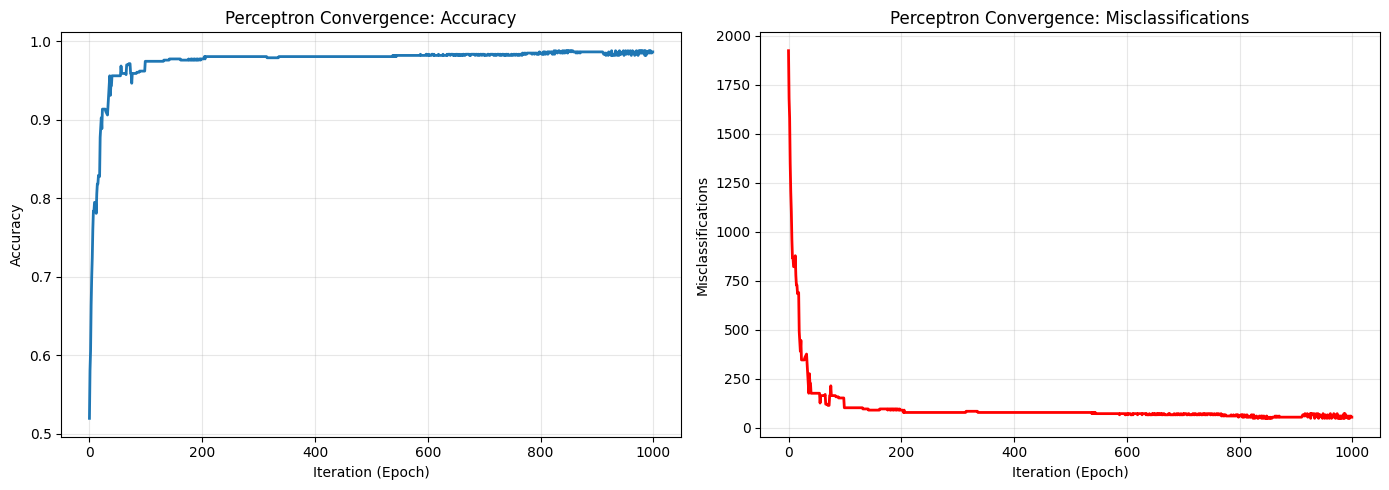

In [19]:
# CONVERGENCE PLOTS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(range(len(accuracies)), accuracies, linewidth=2)
ax1.set_xlabel('Iteration (Epoch)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Perceptron Convergence: Accuracy')
ax1.grid(True, alpha=0.3)

# Misclassifications plot
ax2.plot(range(len(misclass)), misclass, color='red', linewidth=2)
ax2.set_xlabel('Iteration (Epoch)')
ax2.set_ylabel('Misclassifications')
ax2.set_title('Perceptron Convergence: Misclassifications')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Perceptron predictions (these variables should already exist in this notebook)
perceptron_preds = np.where(X @ fin_w >= 0, 1, -1)
perceptron_preds_binary = np.where(perceptron_preds == 1, 1, 0)
y_perceptron = np.array([1 if label == 1 else 0 for label in y])  # y from perceptron

# Create perceptron confusion matrix
cm_perceptron = confusion_matrix(y_perceptron, perceptron_preds_binary)

# Print for now (we'll compare with KNN later)
print("Perceptron Confusion Matrix:")
print(cm_perceptron)
print(f"\nTrue Negatives: {cm_perceptron[0,0]}")
print(f"False Positives: {cm_perceptron[0,1]}")
print(f"False Negatives: {cm_perceptron[1,0]}")
print(f"True Positives: {cm_perceptron[1,1]}")

Perceptron Confusion Matrix:
[[3850    0]
 [  54  102]]

True Negatives: 3850
False Positives: 0
False Negatives: 54
True Positives: 102


In [21]:
accuracy = np.mean(np.where(X @ fin_w >= 0, 1, -1) == y)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 98.65%


# Sklearn

In [24]:
X = np.vstack([np.ones(len(x[0])), x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8], x[9], x[10], x[11], x[12]]).T
y = [1 if super_food else -1 for super_food in df_cleaned['superfood']]
w = np.array([1, -1, 0, -2, 1, 2, 1, 2, 1, -1, 0, -1, 1, 0])

In [33]:
X_new = X[:,1:]
perceptron = SGDClassifier(loss='hinge', max_iter=1000, random_state=42,
                           fit_intercept = True, alpha = .0001, shuffle = True) # set fit_intercept to True

# Train the Perceptron
perceptron.fit(X_new, y)

# Predicting the labels
print(perceptron.predict(X_new))
print(y)
fin_w = np.concatenate([perceptron.intercept_, perceptron.coef_[0]])
print(fin_w) #print final w vector

[-1 -1  1 ... -1 -1 -1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,

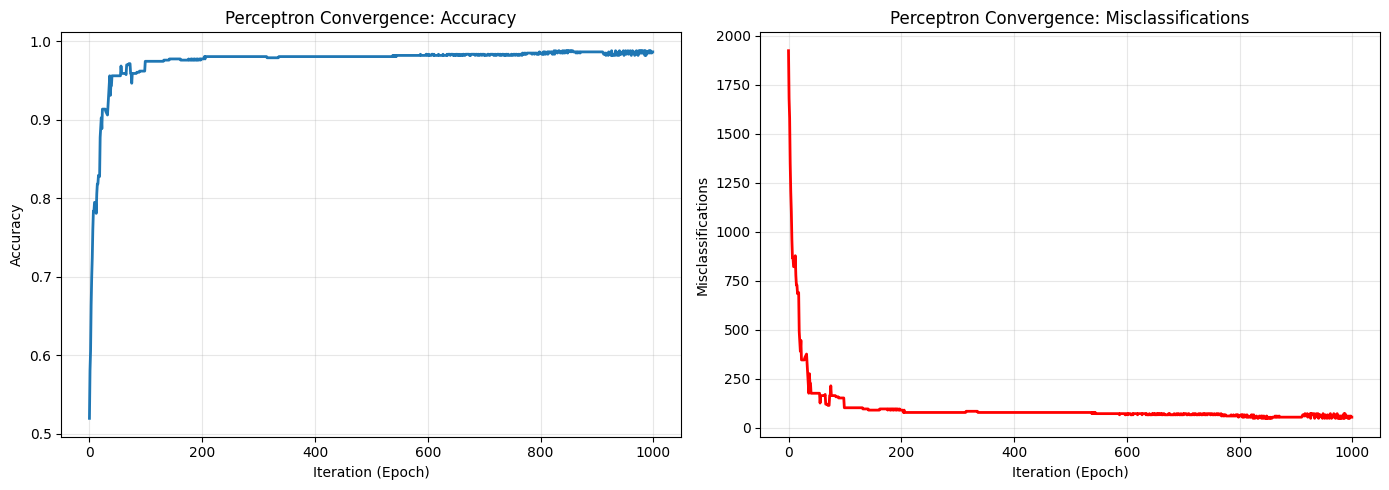

In [34]:
# CONVERGENCE PLOTS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(range(len(accuracies)), accuracies, linewidth=2)
ax1.set_xlabel('Iteration (Epoch)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Perceptron Convergence: Accuracy')
ax1.grid(True, alpha=0.3)

# Misclassifications plot
ax2.plot(range(len(misclass)), misclass, color='red', linewidth=2)
ax2.set_xlabel('Iteration (Epoch)')
ax2.set_ylabel('Misclassifications')
ax2.set_title('Perceptron Convergence: Misclassifications')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Perceptron predictions (these variables should already exist in this notebook)
perceptron_preds = np.where(X @ fin_w >= 0, 1, -1)
perceptron_preds_binary = np.where(perceptron_preds == 1, 1, 0)
y_perceptron = np.array([1 if label == 1 else 0 for label in y])  # y from perceptron

# Create perceptron confusion matrix
cm_perceptron = confusion_matrix(y_perceptron, perceptron_preds_binary)

# Print for now (we'll compare with KNN later)
print("Perceptron Confusion Matrix:")
print(cm_perceptron)
print(f"\nTrue Negatives: {cm_perceptron[0,0]}")
print(f"False Positives: {cm_perceptron[0,1]}")
print(f"False Negatives: {cm_perceptron[1,0]}")
print(f"True Positives: {cm_perceptron[1,1]}")

Perceptron Confusion Matrix:
[[3850    0]
 [  72   84]]

True Negatives: 3850
False Positives: 0
False Negatives: 72
True Positives: 84


In [36]:
accuracy = np.mean(np.where(X @ fin_w >= 0, 1, -1) == y)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 98.20%
